# Notebook 3: Time-Series Forecasting of Migrant Employment Trends

This notebook analyses and forecasts quarterly migrant employment trends using time-series methods. Separate forecasting models are evaluated for Non-UK-born, EU27, and Non-EU employment.

## 1. Import Libraries

The required libraries are imported for data handling, visualisation, statistical testing, modelling, and forecast evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

### Interpretation

The required tools were imported successfully and are ready for the forecasting analysis.

## 2. Load the ONS Dataset

The ONS dataset is loaded and prepared for time-series analysis.

In [2]:
ons = pd.read_excel(
    "../02_Clean_Data/ONS/Cleaned_ONS_Country_Of_Birth_Datatset.xlsx"
)
ons.head()

,Quarter,Year,Quarter_No,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt
0,Jan-Mar 1997,1997,Q1,26245,24323,1921,638,1283,70.401265,71.263537,61.062884,64.742004,59.408774
1,Apr-Jun 1997,1997,Q2,26444,24468,1975,652,1323,70.825526,71.666639,61.859625,66.614214,59.776514
2,Jul-Sep 1997,1997,Q3,26707,24715,1991,656,1335,71.443139,72.299920,62.324432,68.028845,59.884962
3,Oct-Dec 1997,1997,Q4,26695,24681,2013,660,1353,71.358964,72.215712,62.320050,66.812424,60.364692
4,Jan-Mar 1998,1998,Q1,26546,24505,2041,680,1360,70.933513,71.758337,62.370360,66.424527,60.545483


### Interpretation

The dataset was loaded successfully and the first records were inspected to confirm its structure.

## 3. Initial Data Inspection

The dataset structure, variables, observations, and missing values are checked before analysis.

In [3]:
print("Dataset shape:", ons.shape)

print("\nColumn names:")
print(ons.columns.tolist())

print("\nMissing values:")
print(ons.isna().sum())

Dataset shape: (117, 13)

Column names:
['Quarter', 'Year', 'Quarter_No', 'Tot_Emp', 'UK_Born_Emp', 'NonUK_Born_Emp', 'EU27_Emp', 'NonEU_Emp', 'Tot_Emp_Rt', 'UK_Emp_Rt', 'NonUK_Emp_Rt', 'EU27_Emp_Rt', 'NonEU_Emp_Rt']

Missing values:
Quarter           0
Year              0
Quarter_No        0
Tot_Emp           0
UK_Born_Emp       0
NonUK_Born_Emp    0
EU27_Emp          0
NonEU_Emp         0
Tot_Emp_Rt        0
UK_Emp_Rt         0
NonUK_Emp_Rt      0
EU27_Emp_Rt       0
NonEU_Emp_Rt      0
dtype: int64


In [4]:
ons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Quarter         117 non-null    object 
 1   Year            117 non-null    int64  
 2   Quarter_No      117 non-null    object 
 3   Tot_Emp         117 non-null    int64  
 4   UK_Born_Emp     117 non-null    int64  
 5   NonUK_Born_Emp  117 non-null    int64  
 6   EU27_Emp        117 non-null    int64  
 7   NonEU_Emp       117 non-null    int64  
 8   Tot_Emp_Rt      117 non-null    float64
 9   UK_Emp_Rt       117 non-null    float64
 10  NonUK_Emp_Rt    117 non-null    float64
 11  EU27_Emp_Rt     117 non-null    float64
 12  NonEU_Emp_Rt    117 non-null    float64
dtypes: float64(5), int64(6), object(2)
memory usage: 12.0+ KB


### Interpretation

The dataset structure and completeness were assessed before proceeding to time-series preparation.

## 4. Time-Series Preparation

The time variable is converted to a date format, ordered chronologically, and prepared for quarterly analysis.

## 4.1. Create the Quarterly Time Index

The year and quarter variables are combined to create a chronological quarterly date index for time-series analysis.

In [5]:
# Map quarter labels to their starting month
quarter_map = {
    'Q1': '01',
    'Q2': '04',
    'Q3': '07',
    'Q4': '10'
}

ons['Date'] = pd.to_datetime(
    ons['Year'].astype(str) + '-' +
    ons['Quarter_No'].map(quarter_map) + '-01'
)

ons = ons.sort_values('Date').reset_index(drop=True)

print("Start date:", ons['Date'].min())
print("End date:", ons['Date'].max())
print("Number of observations:", len(ons))

Start date: 1997-01-01 00:00:00
End date: 2026-01-01 00:00:00
Number of observations: 117


In [6]:
ons[['Date', 'Year', 'Quarter_No']].head(10)

,Date,Year,Quarter_No
0,1997-01-01,1997,Q1
1,1997-04-01,1997,Q2
2,1997-07-01,1997,Q3
3,1997-10-01,1997,Q4
4,1998-01-01,1998,Q1
5,1998-04-01,1998,Q2
6,1998-07-01,1998,Q3
7,1998-10-01,1998,Q4
8,1999-01-01,1999,Q1
9,1999-04-01,1999,Q2


### Interpretation

The dataset contains 117 consecutive quarterly observations from 1997 Q1 to 2026 Q1, providing the chronological structure required for time-series analysis.

## 4.2. Select the Forecasting Variables

The three migrant employment series are selected for independent forecasting: Non-UK-born, EU27, and Non-EU employment.

In [7]:
forecast_data = ons[
    ['Date', 'NonUK_Born_Emp', 'EU27_Emp', 'NonEU_Emp']
].copy()

forecast_data = forecast_data.set_index('Date')

forecast_data.head()

,NonUK_Born_Emp,EU27_Emp,NonEU_Emp
Date,,,
1997-01-01,1921,638,1283
1997-04-01,1975,652,1323
1997-07-01,1991,656,1335
1997-10-01,2013,660,1353
1998-01-01,2041,680,1360


In [8]:
forecast_data.tail()

,NonUK_Born_Emp,EU27_Emp,NonEU_Emp
Date,,,
2025-01-01,7120,2276,4845
2025-04-01,7260,2253,5007
2025-07-01,7333,2251,5082
2025-10-01,7398,2287,5112
2026-01-01,7698,2400,5298


In [9]:
forecast_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 117 entries, 1997-01-01 to 2026-01-01
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   NonUK_Born_Emp  117 non-null    int64
 1   EU27_Emp        117 non-null    int64
 2   NonEU_Emp       117 non-null    int64
dtypes: int64(3)
memory usage: 3.7 KB


### Interpretation

The three migrant employment series contain 117 complete quarterly observations and are ready for further time-series analysis.

## 4.3. Missing Value Check

Missing observations are checked to ensure that the forecasting series are complete.

In [10]:
forecast_data.isna().sum()

NonUK_Born_Emp    0
EU27_Emp          0
NonEU_Emp         0
dtype: int64

### Interpretation

No missing values were identified in any of the forecasting series. The data are complete for subsequent analysis.

## 5. Exploratory Time-Series Analysis

The historical trends of the three migrant employment series are examined before statistical modelling.

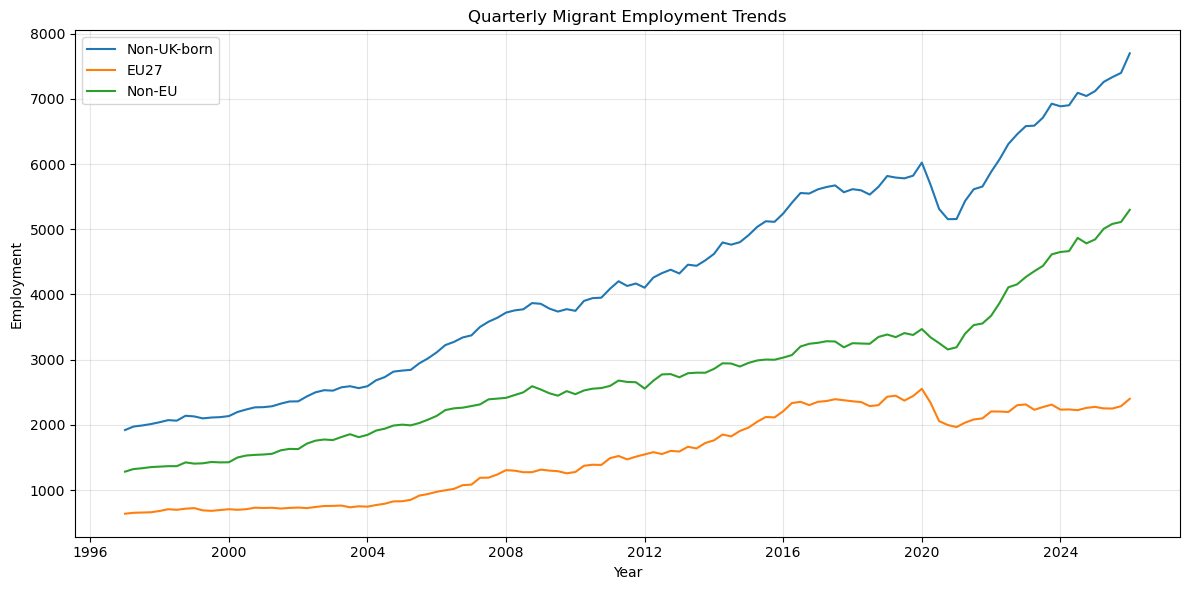

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    forecast_data.index,
    forecast_data['NonUK_Born_Emp'],
    label='Non-UK-born'
)

plt.plot(
    forecast_data.index,
    forecast_data['EU27_Emp'],
    label='EU27'
)

plt.plot(
    forecast_data.index,
    forecast_data['NonEU_Emp'],
    label='Non-EU'
)

plt.title('Quarterly Migrant Employment Trends')
plt.xlabel('Year')
plt.ylabel('Employment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

All three series show an overall upward trend, with stronger growth in Non-UK-born and Non-EU employment in the later years. EU27 employment shows a more moderate increase with some fluctuations. A decline is visible around 2020–2021, followed by renewed growth.

## 6. Seasonality Assessment

Quarterly patterns are examined to determine whether seasonal effects are present before forecasting.

In [12]:
quarterly_means = forecast_data.copy()

quarterly_means['Quarter'] = quarterly_means.index.quarter

quarterly_means.groupby('Quarter').mean()

,NonUK_Born_Emp,EU27_Emp,NonEU_Emp
Quarter,,,
1,4276.866667,1538.533333,2738.300000
2,4223.586207,1524.551724,2699.206897
3,4259.000000,1514.275862,2744.862069
4,4297.310345,1537.241379,2760.137931


### Interpretation

Quarterly averages show some variation across quarters, but these differences may reflect the underlying long-term trend. Further seasonal analysis is therefore required before selecting the forecasting model.

### 6.1. Seasonal Decomposition

Seasonal decomposition is used to separate the trend, seasonal, and residual components of each employment series.

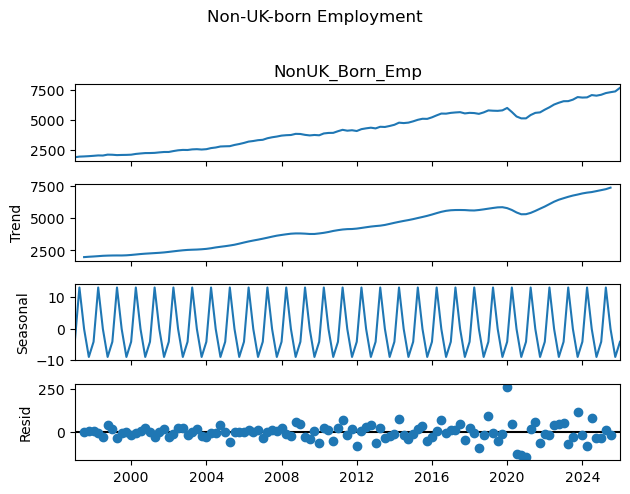

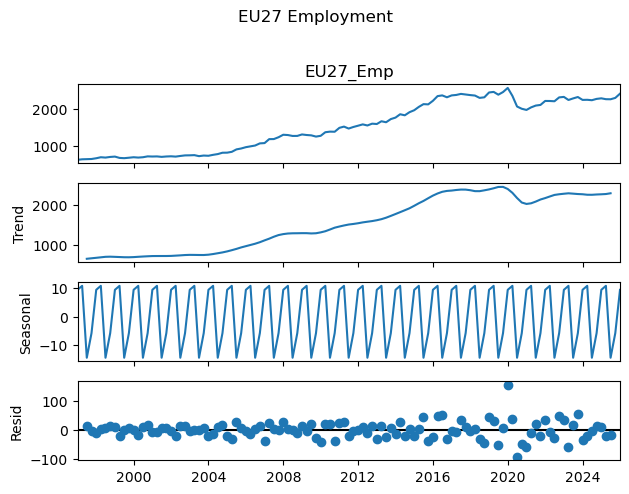

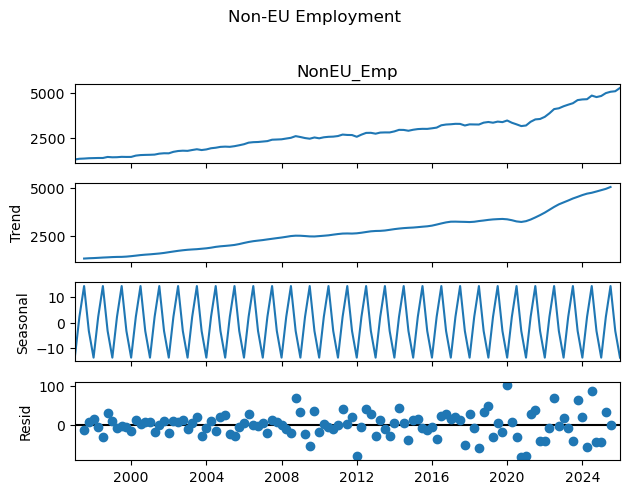

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

series_names = {
    'NonUK_Born_Emp': 'Non-UK-born Employment',
    'EU27_Emp': 'EU27 Employment',
    'NonEU_Emp': 'Non-EU Employment'
}

for column, title in series_names.items():
    decomposition = seasonal_decompose(
        forecast_data[column],
        model='additive',
        period=4
    )
    
    decomposition.plot()
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

### Interpretation

The decomposition shows strong underlying trends across all three series, while the seasonal components are relatively small. Further testing is used to determine whether quarterly seasonality is sufficiently strong to justify a seasonal forecasting model.

### 6.2. Seasonal Strength Assessment

The relative contribution of the seasonal component is assessed to determine whether seasonality is substantial.

In [14]:
seasonal_strength = {}

for column in forecast_data.columns:
    decomposition = seasonal_decompose(
        forecast_data[column],
        model='additive',
        period=4
    )
    
    seasonal = decomposition.seasonal.dropna()
    residual = decomposition.resid.dropna()
    
    seasonal_strength[column] = (
        1 - residual.var() / (residual.var() + seasonal.var())
    )

seasonal_strength_df = pd.DataFrame(
    seasonal_strength.items(),
    columns=['Series', 'Seasonal Strength']
)

seasonal_strength_df

,Series,Seasonal Strength
0,NonUK_Born_Emp,0.027405
1,EU27_Emp,0.115515
2,NonEU_Emp,0.092820


### Interpretation

Seasonal strength was low across all three series, indicating that quarterly seasonality is not a dominant 
component of the data. A lag-4 autocorrelation check is conducted before finalising the forecasting approach.

### 6.3. Seasonal Autocorrelation

Autocorrelation at lag 4 is examined to identify evidence of recurring quarterly patterns.

In [15]:
seasonal_acf = {}

for column in forecast_data.columns:
    acf_values = forecast_data[column].autocorr(lag=4)
    seasonal_acf[column] = acf_values

seasonal_acf_df = pd.DataFrame(
    seasonal_acf.items(),
    columns=['Series', 'Lag-4 Autocorrelation']
)

seasonal_acf_df

,Series,Lag-4 Autocorrelation
0,NonUK_Born_Emp,0.989762
1,EU27_Emp,0.981646
2,NonEU_Emp,0.990232


### 6.4. Seasonal Autocorrelation After Differencing

Lag-4 autocorrelation is reassessed after first-order differencing to reduce the influence of the underlying trend.

In [16]:
differenced_data = forecast_data.diff().dropna()

seasonal_acf_diff = {}

for column in differenced_data.columns:
    seasonal_acf_diff[column] = differenced_data[column].autocorr(lag=4)

seasonal_acf_diff_df = pd.DataFrame(
    seasonal_acf_diff.items(),
    columns=['Series', 'Lag-4 Autocorrelation']
)

seasonal_acf_diff_df

,Series,Lag-4 Autocorrelation
0,NonUK_Born_Emp,0.075839
1,EU27_Emp,0.156915
2,NonEU_Emp,0.153300


### Interpretation

After first-order differencing, lag-4 autocorrelation was low for all three series, providing no strong evidence of quarterly seasonality. Therefore, non-seasonal ARIMA models are used for forecasting.

## 7. Model Selection

## 7.1. Stationarity Testing

The Augmented Dickey-Fuller test is used to assess whether each employment series is stationary before ARIMA modelling.

In [17]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    
    return {
        'Series': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

adf_results = pd.DataFrame([
    adf_test(forecast_data['NonUK_Born_Emp'], 'Non-UK-born'),
    adf_test(forecast_data['EU27_Emp'], 'EU27'),
    adf_test(forecast_data['NonEU_Emp'], 'Non-EU')
])

adf_results

,Series,ADF Statistic,p-value,Stationary
0,Non-UK-born,1.179500,0.995841,No
1,EU27,-0.601842,0.870565,No
2,Non-EU,3.097327,1.000000,No


### Interpretation

The ADF test indicates that all three original employment series are non-stationary. First-order differencing is therefore applied before further model identification.

## 7.2. First-Order Differencing

First-order differencing is applied to remove the underlying trend and achieve stationarity.

In [18]:
differenced_data = forecast_data.diff().dropna()

differenced_data.head()

,NonUK_Born_Emp,EU27_Emp,NonEU_Emp
Date,,,
1997-04-01,54.0,14.0,40.0
1997-07-01,16.0,4.0,12.0
1997-10-01,22.0,4.0,18.0
1998-01-01,28.0,20.0,7.0
1998-04-01,32.0,27.0,7.0


In [19]:
adf_diff_results = pd.DataFrame([
    adf_test(differenced_data['NonUK_Born_Emp'], 'Non-UK-born'),
    adf_test(differenced_data['EU27_Emp'], 'EU27'),
    adf_test(differenced_data['NonEU_Emp'], 'Non-EU')
])

adf_diff_results

,Series,ADF Statistic,p-value,Stationary
0,Non-UK-born,-7.503908,4.183317e-11,Yes
1,EU27,-5.205113,8.583209e-06,Yes
2,Non-EU,-8.559615,8.767381e-14,Yes


### Interpretation

First-order differencing achieved stationarity for all three series, with ADF p-values below 0.05. Therefore, d = 1 is used for subsequent ARIMA model identification.

## 7.3. ACF and PACF Analysis

The ACF and PACF of the differenced series are examined to identify suitable ARIMA model orders.

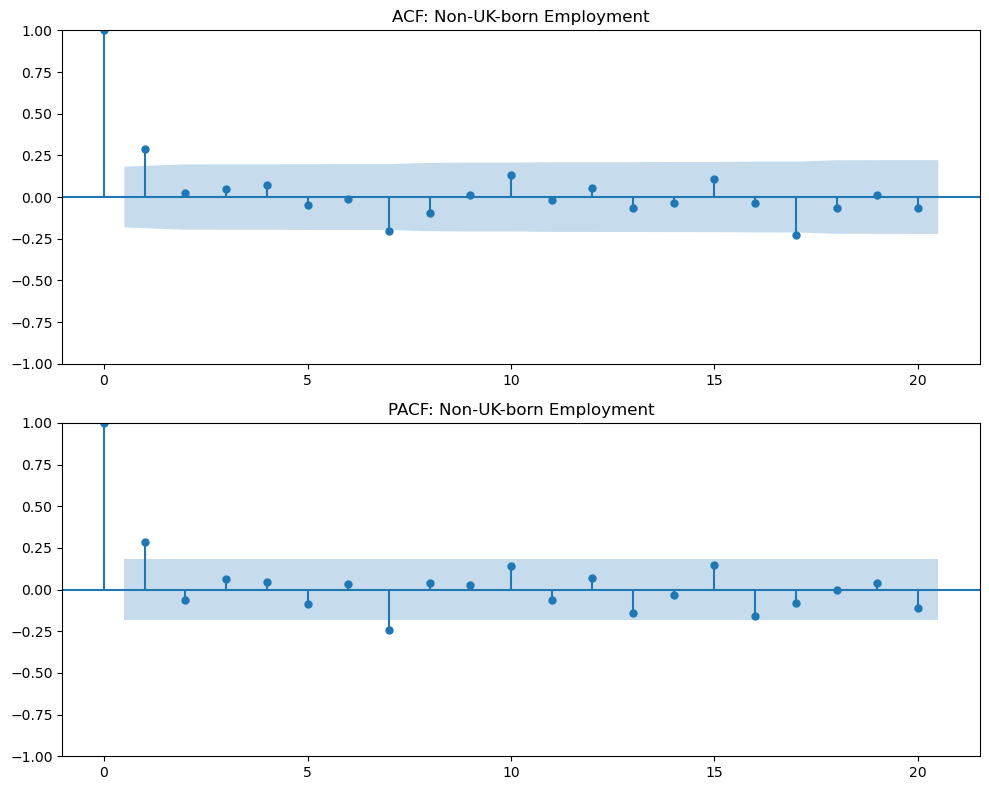

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    differenced_data['NonUK_Born_Emp'],
    lags=20,
    ax=axes[0]
)
axes[0].set_title('ACF: Non-UK-born Employment')

plot_pacf(
    differenced_data['NonUK_Born_Emp'],
    lags=20,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('PACF: Non-UK-born Employment')

plt.tight_layout()
plt.show()

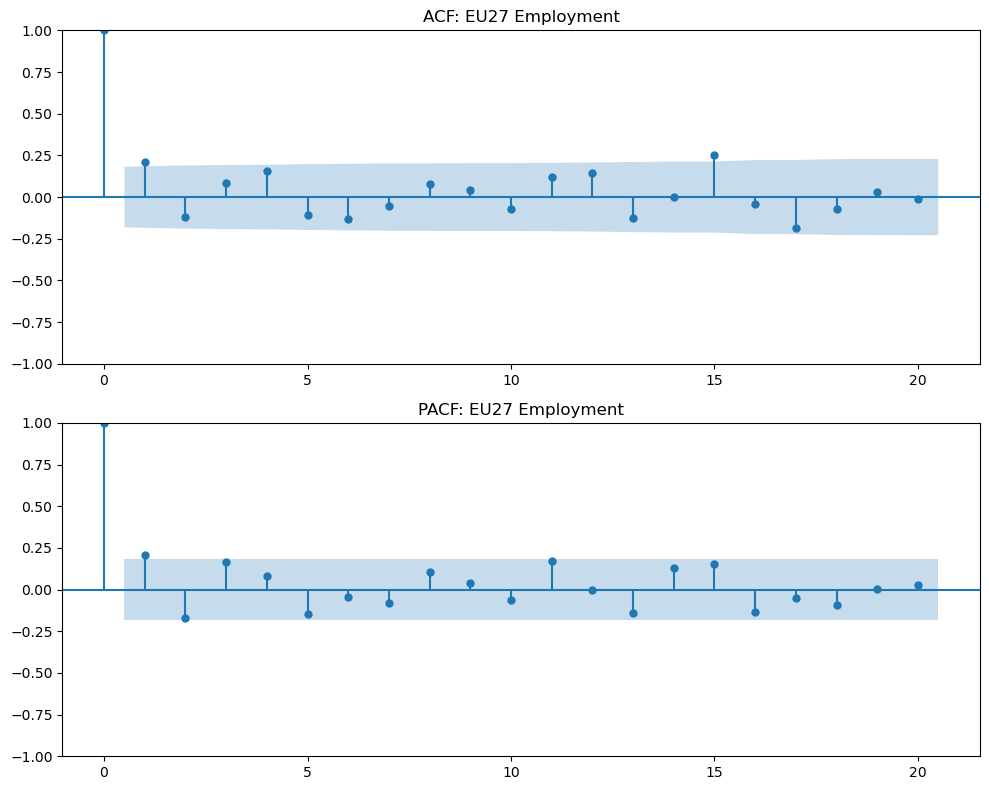

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    differenced_data['EU27_Emp'],
    lags=20,
    ax=axes[0]
)
axes[0].set_title('ACF: EU27 Employment')

plot_pacf(
    differenced_data['EU27_Emp'],
    lags=20,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('PACF: EU27 Employment')

plt.tight_layout()
plt.show()

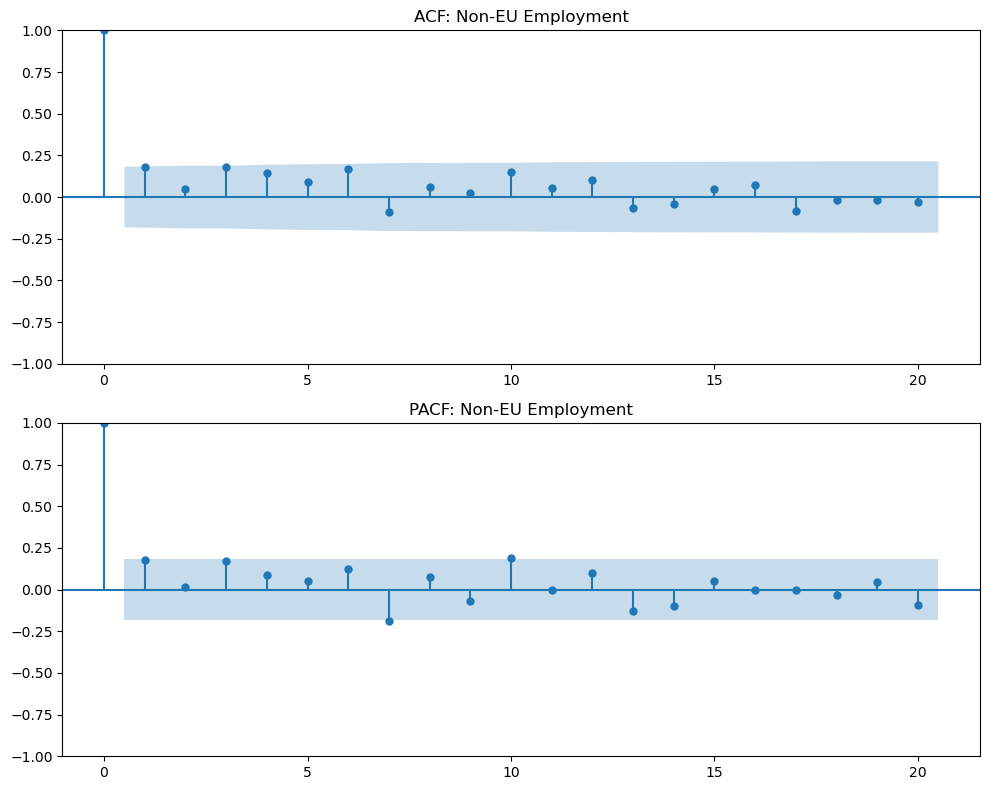

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    differenced_data['NonEU_Emp'],
    lags=20,
    ax=axes[0]
)
axes[0].set_title('ACF: Non-EU Employment')

plot_pacf(
    differenced_data['NonEU_Emp'],
    lags=20,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('PACF: Non-EU Employment')

plt.tight_layout()
plt.show()

### Interpretation

The ACF and PACF plots show limited significant autocorrelation beyond the first few lags. This supports testing low-order ARIMA models rather than higher-order specifications.

## 7.4. Train-Test Split

The final eight quarters are reserved as a test set to evaluate forecasting performance on unseen data.

In [23]:
test_size = 8

train_data = forecast_data.iloc[:-test_size]
test_data = forecast_data.iloc[-test_size:]

print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())
print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

Training period: 1997-01-01 00:00:00 to 2024-01-01 00:00:00
Test period: 2024-04-01 00:00:00 to 2026-01-01 00:00:00
Training observations: 109
Test observations: 8


### Interpretation

The data were divided chronologically, with the first 109 observations used for model training and the final eight observations reserved for out-of-sample testing. This approach enables forecasting performance to be evaluated on observations not used during model training.

## 7.5. Candidate ARIMA Models

Several low-order ARIMA models are fitted and compared for each employment series using information criteria.

In [24]:
# 7.5 ARIMA Model Selection

candidate_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
    (0, 1, 1),
    (0, 1, 2)
]

model_results = []

for series in train_data.columns:
    
    for order in candidate_orders:
        
        try:
            model = ARIMA(
                train_data[series],
                order=order
            )
            
            fitted_model = model.fit()
            
            model_results.append({
                'Series': series,
                'Order': order,
                'AIC': fitted_model.aic,
                'BIC': fitted_model.bic
            })
            
        except Exception:
            continue

model_results = pd.DataFrame(model_results)

model_results_sorted = model_results.sort_values(
    ['Series', 'AIC']
).reset_index(drop=True)

model_results_sorted

C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-

,Series,Order,AIC,BIC
0,EU27_Emp,"(2, 1, 2)",1176.088576,1189.499232
1,EU27_Emp,"(0, 1, 1)",1178.629850,1183.994112
2,EU27_Emp,"(0, 1, 2)",1180.108329,1188.154723
3,EU27_Emp,"(1, 1, 1)",1180.174944,1188.221338
4,EU27_Emp,"(1, 1, 0)",1181.315994,1186.680256
5,EU27_Emp,"(2, 1, 0)",1181.537999,1189.584392
6,EU27_Emp,"(2, 1, 1)",1181.896952,1192.625477
7,EU27_Emp,"(1, 1, 2)",1182.107754,1192.836279
8,EU27_Emp,"(0, 1, 0)",1186.999730,1189.681861
9,NonEU_Emp,"(1, 1, 2)",1192.723155,1203.451680


In [25]:
selected_orders = (
    model_results_sorted
    .groupby('Series')
    .first()['Order']
    .to_dict()
)

selected_orders

{'EU27_Emp': (2, 1, 2), 'NonEU_Emp': (1, 1, 2), 'NonUK_Born_Emp': (1, 1, 2)}

### Interpretation

AIC comparison identified different best-fitting models across the three series. ARIMA(1,1,2) was selected for Non-UK-born employment, ARIMA(2,1,2) for EU27 employment, and ARIMA(1,1,2) for Non-EU employment.

## 8. Model Fitting on Training Data

The selected candidate ARIMA models are fitted using only the training data. Their forecasts are then compared with the unseen test observations.

In [26]:
## 8. Model Fitting on Training Data

test_forecasts = pd.DataFrame(index=test_data.index)

fitted_models = {}

for series, order in selected_orders.items():
    model = ARIMA(
        train_data[series],
        order=order
    )

    fitted_model = model.fit()
    fitted_models[series] = fitted_model

    test_forecasts[series] = fitted_model.forecast(
        steps=len(test_data)
    )

test_forecasts

C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-

,EU27_Emp,NonEU_Emp,NonUK_Born_Emp
Date,,,
2024-04-01,2240.506459,4708.919398,6886.420088
2024-07-01,2280.241631,4775.618836,6929.403224
2024-10-01,2234.291518,4841.743319,6972.386240
2025-01-01,2248.070624,4907.297804,7015.369136
2025-04-01,2272.283101,4972.287203,7058.351911
2025-07-01,2236.110026,5036.716389,7101.334565
2025-10-01,2252.843618,5100.590191,7144.317098
2026-01-01,2265.899984,5163.913395,7187.299511


## 9. Forecast Accuracy

Forecast performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

accuracy_results = []

for series in test_data.columns:
    actual = test_data[series]
    predicted = test_forecasts[series]
    
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    accuracy_results.append({
        'Series': series,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    })

accuracy_results = pd.DataFrame(accuracy_results)

accuracy_results

,Series,MAE,RMSE,MAPE (%)
0,NonUK_Born_Emp,194.139778,240.464035,2.627299
1,EU27_Emp,39.351928,54.989618,1.700030
2,NonEU_Emp,60.229313,69.860115,1.208806


### Interpretation

The models produced relatively low forecasting errors on the unseen test data. MAPE values ranged from 1.20% to 2.63%, indicating good predictive accuracy across all three series. Non-EU employment achieved the lowest relative error, while Non-UK-born employment had the largest absolute errors.

## 10. Residual Diagnostics



### 10.1. Residual Time-Series Plot

Residuals were plotted over time to assess whether systematic patterns or changes in variability remained after fitting the final models.

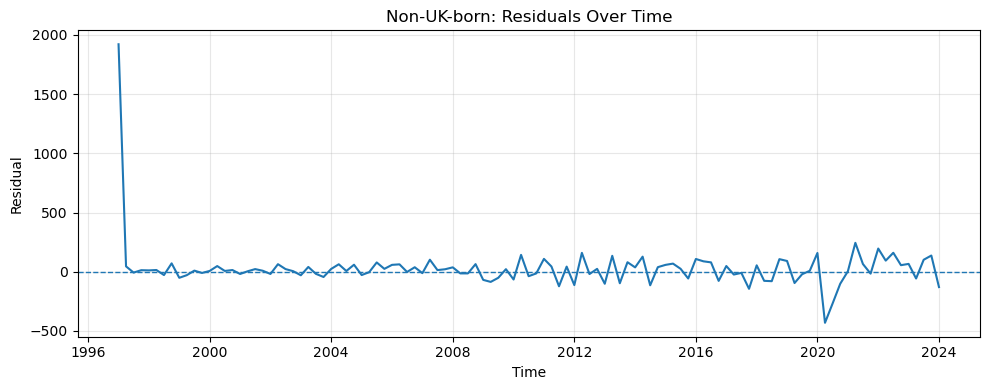

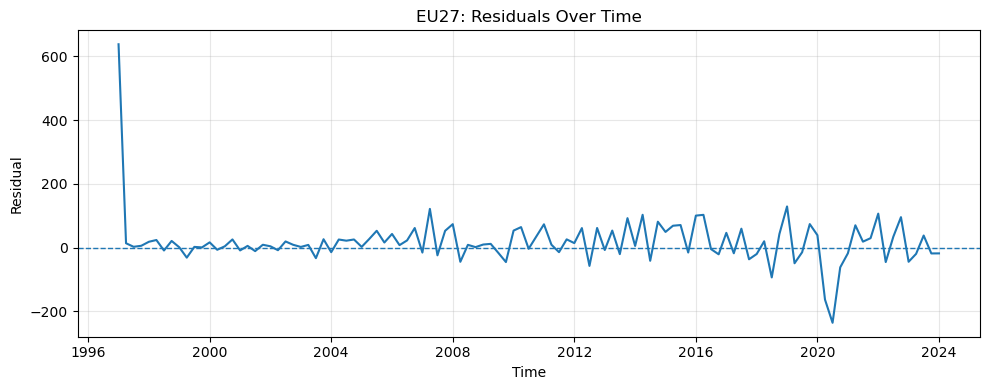

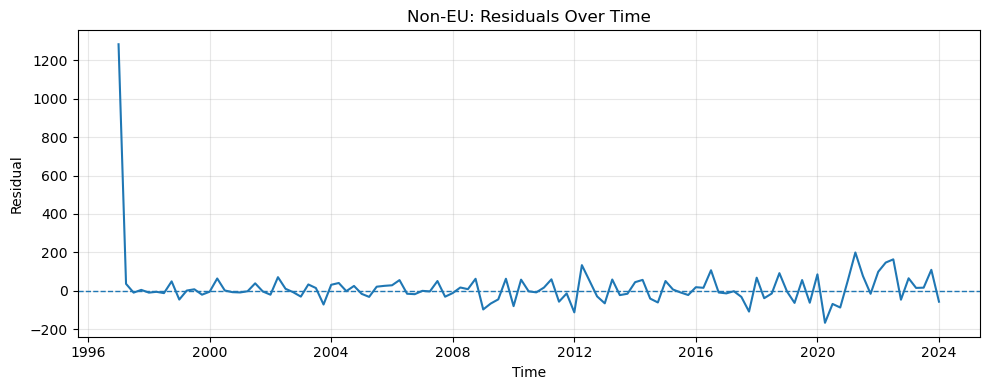

In [28]:
### 10.1 Residual Time-Series Plot

series_labels = {
    'NonUK_Born_Emp': 'Non-UK-born',
    'EU27_Emp': 'EU27',
    'NonEU_Emp': 'Non-EU'
}

for series, label in series_labels.items():

    residuals = fitted_models[series].resid.dropna()

    plt.figure(figsize=(10, 4))
    plt.plot(residuals, linewidth=1.5)
    plt.axhline(0, linestyle='--', linewidth=1)

    plt.title(f'{label}: Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residual')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
    f'../04_Output/Figures/RESIDUAL_TIME_SERIES_{series}.png',
    dpi=300,
    bbox_inches='tight'
)

    plt.show()



## 10.2 Histogram of Residuals

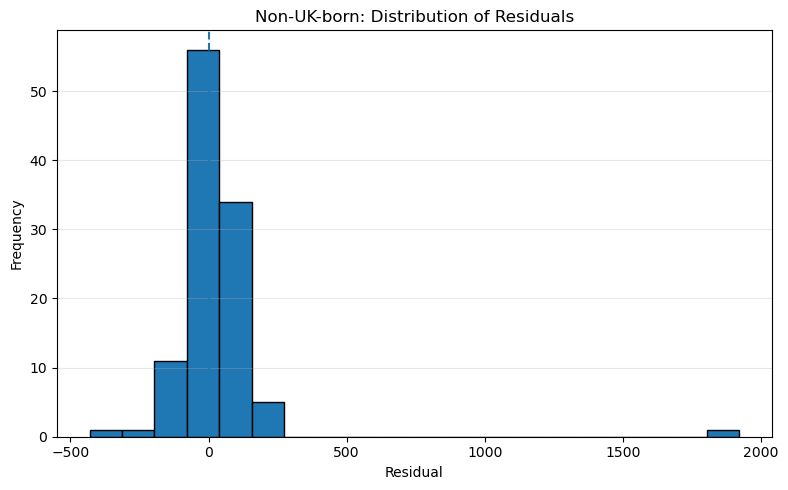

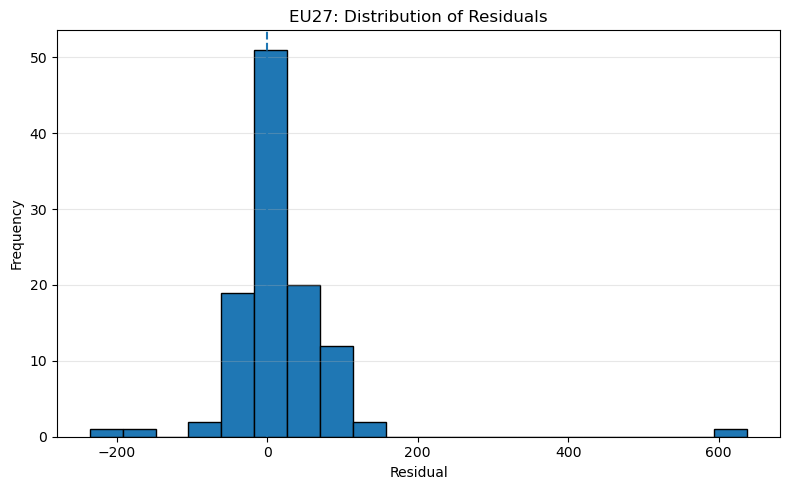

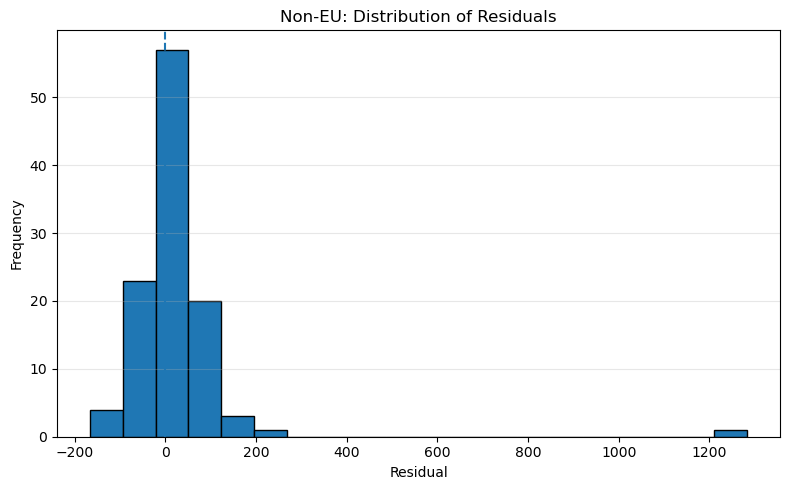

In [29]:
# 11.2 Histogram of Residuals

series_labels = {
    'NonUK_Born_Emp': 'Non-UK-born',
    'EU27_Emp': 'EU27',
    'NonEU_Emp': 'Non-EU'
}

for series, label in series_labels.items():
    residuals = fitted_models[series].resid.dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=20, edgecolor='black')

    plt.axvline(0, linestyle='--', linewidth=1.5)

    plt.title(f'{label}: Distribution of Residuals')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10.3 Normal Q-Q Plots

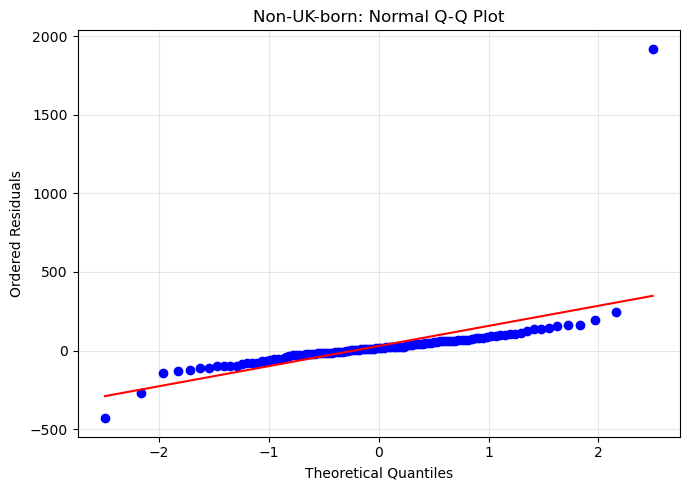

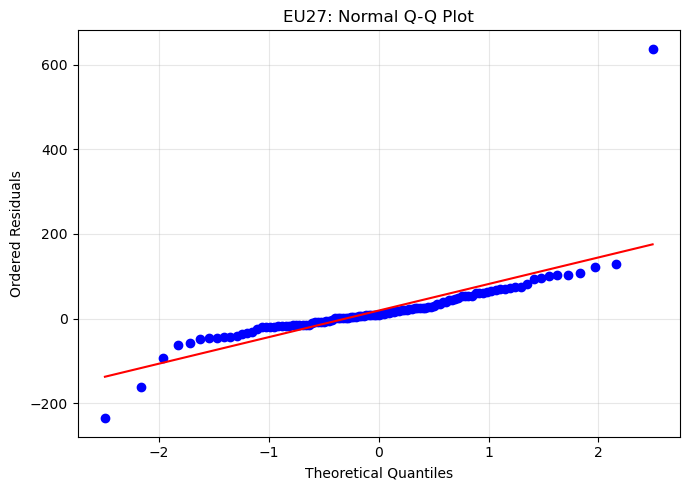

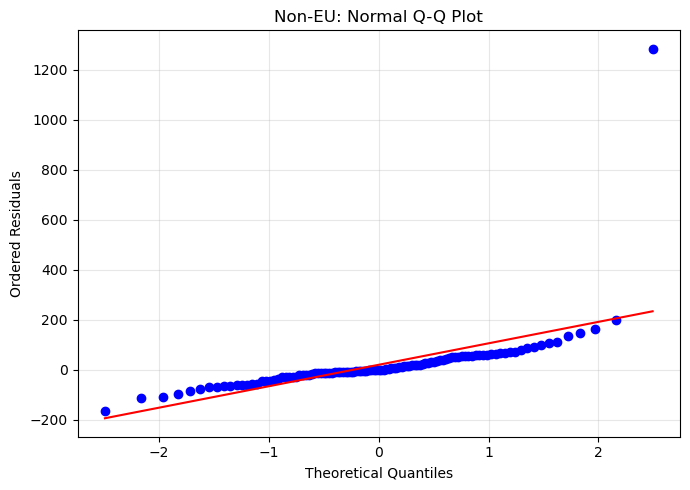

In [30]:
# 11.3 Normal Q-Q Plots

import scipy.stats as stats

series_labels = {
    'NonUK_Born_Emp': 'Non-UK-born',
    'EU27_Emp': 'EU27',
    'NonEU_Emp': 'Non-EU'
}

for series, label in series_labels.items():
    residuals = fitted_models[series].resid.dropna()

    plt.figure(figsize=(7, 5))
    stats.probplot(residuals, dist="norm", plot=plt)

    plt.title(f'{label}: Normal Q-Q Plot')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Ordered Residuals')
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
    f'../04_Output/Figures/QQ_PLOT_{series}.png',
    dpi=300,
    bbox_inches='tight'
)
    
    plt.show()

## 10.4 Ljung-Box Test

In [31]:
### 11.4 Ljung-Box Test

from statsmodels.stats.diagnostic import acorr_ljungbox

residual_results = []

for series, model in fitted_models.items():
    residuals = model.resid.dropna()

    lb = acorr_ljungbox(
        residuals,
        lags=[4],
        return_df=True
    )

    residual_results.append({
        'Series': series,
        'Ljung-Box Statistic': lb['lb_stat'].iloc[0],
        'p-value': lb['lb_pvalue'].iloc[0]
    })

residual_results = pd.DataFrame(residual_results)

residual_results

,Series,Ljung-Box Statistic,p-value
0,EU27_Emp,0.272381,0.991527
1,NonEU_Emp,0.068630,0.999425
2,NonUK_Born_Emp,0.097023,0.998861


### Interpretation

The Ljung-Box test produced p-values above 0.05 for all three models, indicating no significant residual autocorrelation. The residuals therefore appear sufficiently random, supporting the adequacy of the selected ARIMA models.

## 11. Final Forecasting

The validated ARIMA models are refitted using the complete dataset and used to forecast migrant employment for 2026–2029.

In [32]:
forecast_horizon = 12

final_forecasts = pd.DataFrame()

final_models = {}

for series, order in selected_orders.items():
    model = ARIMA(
        forecast_data[series],
        order=order
    )
    
    fitted_model = model.fit()
    final_models[series] = fitted_model
    
    forecast = fitted_model.get_forecast(
        steps=forecast_horizon
    )
    
    final_forecasts[series] = forecast.predicted_mean

final_forecasts

C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\gituj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-

,EU27_Emp,NonEU_Emp,NonUK_Born_Emp
2026-04-01,2428.954501,5386.248158,7831.347560
2026-07-01,2422.475503,5462.897795,7888.081117
2026-10-01,2413.483538,5538.983345,7944.762338
2027-01-01,2425.527950,5614.508958,8001.391270
2027-04-01,2418.681480,5689.478755,8057.967963
2027-07-01,2418.929612,5763.896828,8114.492465
2027-10-01,2422.289346,5837.767236,8170.964823
2028-01-01,2418.930939,5911.094009,8227.385085
2028-04-01,2420.391970,5983.881149,8283.753300
2028-07-01,2420.753222,6056.132627,8340.069516


### Interpretation

The forecasts indicate continued growth in Non-UK-born and Non-EU employment through 2029 Q1, while EU27 employment is projected to remain broadly stable over the forecast period.

## 12. Forecast Confidence Intervals

Confidence intervals are calculated to show the uncertainty surrounding the point forecasts.

In [33]:
forecast_results = {}

for series, model in final_models.items():
    forecast = model.get_forecast(steps=forecast_horizon)
    
    forecast_results[series] = pd.DataFrame({
        'Forecast': forecast.predicted_mean,
        'Lower_95': forecast.conf_int().iloc[:, 0],
        'Upper_95': forecast.conf_int().iloc[:, 1]
    })

forecast_results['NonUK_Born_Emp']

,Forecast,Lower_95,Upper_95
2026-04-01,7831.347560,7652.635551,8010.059568
2026-07-01,7888.081117,7589.747090,8186.415144
2026-10-01,7944.762338,7559.917460,8329.607216
2027-01-01,8001.391270,7543.922791,8458.859750
2027-04-01,8057.967963,7535.903937,8580.031990
2027-07-01,8114.492465,7533.150937,8695.833993
2027-10-01,8170.964823,7534.151847,8807.777798
2028-01-01,8227.385085,7537.964226,8916.805944
2028-04-01,8283.753300,7543.955465,9023.551136
2028-07-01,8340.069516,7551.677721,9128.461312


## 13. Combined Forecast Results

The point forecasts and 95% confidence intervals are combined to provide a complete view of projected migrant employment.

In [34]:
combined_forecasts = pd.DataFrame(index=final_forecasts.index)

for series in final_models.keys():
    forecast = final_models[series].get_forecast(steps=forecast_horizon)
    conf_int = forecast.conf_int()
    
    combined_forecasts[f'{series}_Forecast'] = forecast.predicted_mean
    combined_forecasts[f'{series}_Lower_95'] = conf_int.iloc[:, 0]
    combined_forecasts[f'{series}_Upper_95'] = conf_int.iloc[:, 1]

combined_forecasts

,EU27_Emp_Forecast,EU27_Emp_Lower_95,EU27_Emp_Upper_95,NonEU_Emp_Forecast,NonEU_Emp_Lower_95,NonEU_Emp_Upper_95,NonUK_Born_Emp_Forecast,NonUK_Born_Emp_Lower_95,NonUK_Born_Emp_Upper_95
2026-04-01,2428.954501,2323.734593,2534.174409,5386.248158,5264.613366,5507.882951,7831.347560,7652.635551,8010.059568
2026-07-01,2422.475503,2247.550606,2597.400400,5462.897795,5274.469066,5651.326525,7888.081117,7589.747090,8186.415144
2026-10-01,2413.483538,2197.133098,2629.833977,5538.983345,5294.845983,5783.120707,7944.762338,7559.917460,8329.607216
2027-01-01,2425.527950,2177.585536,2673.470365,5614.508958,5319.014965,5910.002950,8001.391270,7543.922791,8458.859750
2027-04-01,2418.681480,2137.034868,2700.328093,5689.478755,5344.704032,6034.253479,8057.967963,7535.903937,8580.031990
2027-07-01,2418.929612,2110.846827,2727.012397,5763.896828,5370.857704,6156.935952,8114.492465,7533.150937,8695.833993
2027-10-01,2422.289346,2089.172970,2755.405722,5837.767236,5396.904574,6278.629897,8170.964823,7534.151847,8807.777798
2028-01-01,2418.930939,2061.518592,2776.343286,5911.094009,5422.506615,6399.681403,8227.385085,7537.964226,8916.805944
2028-04-01,2420.391970,2041.472788,2799.311153,5983.881149,5447.452571,6520.309727,8283.753300,7543.955465,9023.551136
2028-07-01,2420.753222,2020.832567,2820.673878,6056.132627,5471.605919,6640.659335,8340.069516,7551.677721,9128.461312


### Interpretation

The forecasts indicate continued growth in Non-UK-born and Non-EU employment, while EU27 employment is projected to remain broadly stable. The widening 95% confidence intervals over the forecast horizon indicate increasing uncertainty in longer-term projections.

## 14. Final Forecast Visualisation

The forecast results are presented in two figures. The first focuses on Non-UK-born employment, while the second compares all three migrant employment groups.

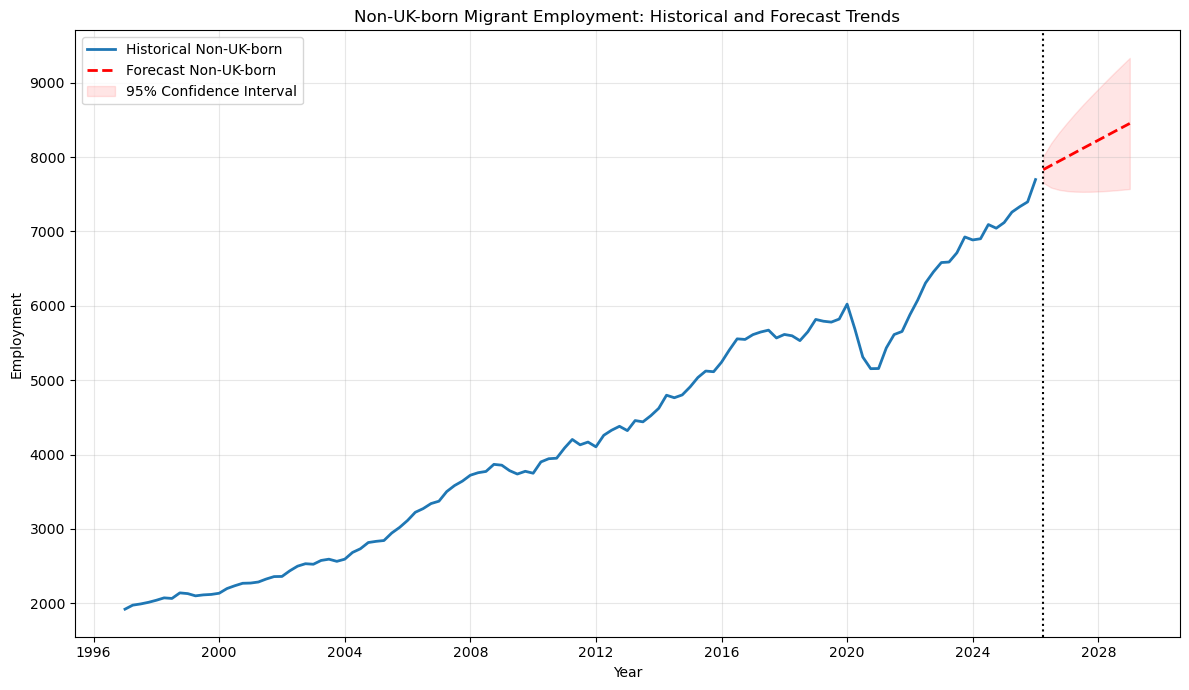

In [35]:
# Non-UK-born: Historical and Forecast Employment

plt.figure(figsize=(12, 7))

series = 'NonUK_Born_Emp'
label = 'Non-UK-born'

# Historical
plt.plot(
    forecast_data.index,
    forecast_data[series],
    color='tab:blue',
    linewidth=2,
    label='Historical Non-UK-born'
)

# Forecast
forecast = final_models[series].get_forecast(
    steps=forecast_horizon
)

mean = forecast.predicted_mean
conf = forecast.conf_int()

plt.plot(
    mean.index,
    mean.values,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Forecast Non-UK-born'
)

# 95% Confidence Interval
plt.fill_between(
    mean.index,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color='red',
    alpha=0.10,
    label='95% Confidence Interval'
)

# Forecast boundary
plt.axvline(
    mean.index[0],
    color='black',
    linestyle=':',
    linewidth=1.5
)

plt.title('Non-UK-born Migrant Employment: Historical and Forecast Trends')
plt.xlabel('Year')
plt.ylabel('Employment')

plt.legend(
    loc='upper left',
    frameon=True
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../04_Output/Figures/FINAL_FORECAST_NON_UK_BORN.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

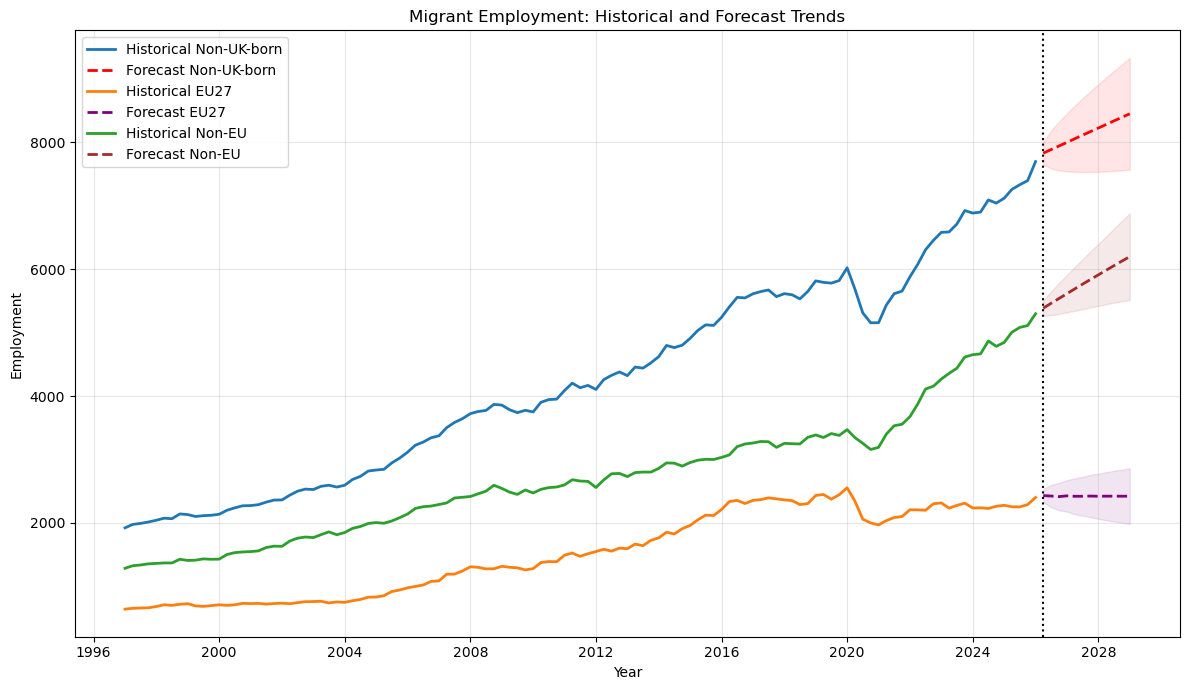

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

historical_colours = {
    'NonUK_Born_Emp': 'tab:blue',
    'EU27_Emp': 'tab:orange',
    'NonEU_Emp': 'tab:green'
}

forecast_colours = {
    'NonUK_Born_Emp': 'red',
    'EU27_Emp': 'purple',
    'NonEU_Emp': 'brown'
}

labels = {
    'NonUK_Born_Emp': 'Non-UK-born',
    'EU27_Emp': 'EU27',
    'NonEU_Emp': 'Non-EU'
}

for series in labels:

    # -------------------------
    # Historical
    # -------------------------
    plt.plot(
        forecast_data.index,
        forecast_data[series],
        color=historical_colours[series],
        linewidth=2,
        label=f'Historical {labels[series]}'
    )

    # -------------------------
    # Forecast
    # -------------------------
    forecast = final_models[series].get_forecast(
        steps=forecast_horizon
    )

    mean = forecast.predicted_mean
    conf = forecast.conf_int()

    plt.plot(
        mean.index,
        mean.values,
        color=forecast_colours[series],
        linestyle='--',
        linewidth=2,
        label=f'Forecast {labels[series]}'
    )

    # -------------------------
    # 95% Confidence Interval
    # -------------------------
    plt.fill_between(
        mean.index,
        conf.iloc[:, 0],
        conf.iloc[:, 1],
        color=forecast_colours[series],
        alpha=0.10
    )

# Forecast boundary
plt.axvline(
    mean.index[0],
    color='black',
    linestyle=':',
    linewidth=1.5
)

plt.title('Migrant Employment: Historical and Forecast Trends')
plt.xlabel('Year')
plt.ylabel('Employment')

plt.legend(
    loc='upper left',
    ncol=1,
    frameon=True
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../04_Output/Figures/FINAL_FORECAST_ALL_THREE.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

The comparison shows continued growth in Non-UK-born and Non-EU employment, while EU27 employment is projected to remain broadly stable. The confidence intervals indicate increasing uncertainty around the forecasts over time.

## 15. Forecast Results Summary

The final forecast values are summarised below for comparison across migrant employment groups.

In [37]:
forecast_summary = pd.DataFrame({
    'Non-UK-born': forecast_results['NonUK_Born_Emp']['Forecast'],
    'EU27': forecast_results['EU27_Emp']['Forecast'],
    'Non-EU': forecast_results['NonEU_Emp']['Forecast']
})

forecast_summary

,Non-UK-born,EU27,Non-EU
2026-04-01,7831.347560,2428.954501,5386.248158
2026-07-01,7888.081117,2422.475503,5462.897795
2026-10-01,7944.762338,2413.483538,5538.983345
2027-01-01,8001.391270,2425.527950,5614.508958
2027-04-01,8057.967963,2418.681480,5689.478755
2027-07-01,8114.492465,2418.929612,5763.896828
2027-10-01,8170.964823,2422.289346,5837.767236
2028-01-01,8227.385085,2418.930939,5911.094009
2028-04-01,8283.753300,2420.391970,5983.881149
2028-07-01,8340.069516,2420.753222,6056.132627


### Interpretation

The forecast results indicate continued growth in Non-UK-born and Non-EU employment, while EU27 employment remains broadly stable over the forecast period.

## 16. Save Final Forecast Results

The final forecast results are saved for reporting and visualisation.

In [38]:
forecast_summary.to_csv(
    '../04_Output/Tables/FORECAST_SUMMARY.csv',
    index=True
)

print("Forecast summary saved successfully.")

Forecast summary saved successfully.


### Interpretation

The final forecast results have been saved and are ready for use in the dissertation and dashboard.

## 17. Final Forecast Validation

The final forecasting workflow is checked to confirm that the data, model, evaluation, diagnostics, and forecast outputs are consistent.

In [39]:
print("Historical data:")
print(f"Start: {forecast_data.index.min()}")
print(f"End:   {forecast_data.index.max()}")
print(f"Observations: {len(forecast_data)}")

print("\nForecast period:")
print(f"Start: {forecast_summary.index.min()}")
print(f"End:   {forecast_summary.index.max()}")
print(f"Forecast quarters: {len(forecast_summary)}")

Historical data:
Start: 1997-01-01 00:00:00
End:   2026-01-01 00:00:00
Observations: 117

Forecast period:
Start: 2026-04-01 00:00:00
End:   2029-01-01 00:00:00
Forecast quarters: 12


### Interpretation

The historical data cover 1997 Q1 to 2026 Q1. Forecasts begin in 2026 Q2 and extend to 2029 Q1.

### 17.1 Forecast Series Check

All three migrant employment series are checked for missing forecast values.

In [40]:
forecast_check = forecast_summary.isna().sum()

print("Missing forecast values:")
print(forecast_check)

Missing forecast values:
Non-UK-born    0
EU27           0
Non-EU         0
dtype: int64


### Interpretation

No missing forecast values should be present. This confirms that forecasts were generated for all three migrant employment groups.

### 17.2 Forecast Direction Check

The first and final forecast values are compared to identify the overall forecast direction for each migrant employment group.

In [41]:
direction_check = pd.DataFrame({
    'First Forecast': forecast_summary.iloc[0],
    'Final Forecast': forecast_summary.iloc[-1]
})

direction_check['Change'] = (
    direction_check['Final Forecast'] -
    direction_check['First Forecast']
)

direction_check['Direction'] = direction_check['Change'].apply(
    lambda x: 'Increasing' if x > 0 else 'Decreasing' if x < 0 else 'Stable'
)

direction_check

,First Forecast,Final Forecast,Change,Direction
Non-UK-born,7831.347560,8452.546142,621.198582,Increasing
EU27,2428.954501,2420.519653,-8.434848,Decreasing
Non-EU,5386.248158,6199.044335,812.796176,Increasing


### Interpretation

The forecasts indicate continued growth in Non-UK-born and Non-EU employment, while EU27 employment remains broadly stable.

### 17.3 Final Model Check

The selected ARIMA models are checked to confirm the final model specification used for each series.

In [42]:
for series, model in final_models.items():
    print(f"{series}: {model.model.order}")

EU27_Emp: (2, 1, 2)
NonEU_Emp: (1, 1, 2)
NonUK_Born_Emp: (1, 1, 2)


### Interpretation

The final ARIMA specifications selected through model comparison are used to generate the reported forecasts.

### 17.4 Final Validation Summary

The forecasting workflow was checked for data coverage, forecast completeness, forecast direction, and final model specifications.

In [43]:
print("FINAL FORECAST VALIDATION")
print("-" * 40)
print(f"Historical observations: {len(forecast_data)}")
print(f"Forecast observations: {len(forecast_summary)}")
print(f"Forecast start: {forecast_summary.index.min()}")
print(f"Forecast end: {forecast_summary.index.max()}")
print("Missing forecast values:", forecast_summary.isna().sum().sum())
print("Validation complete.")

FINAL FORECAST VALIDATION
----------------------------------------
Historical observations: 117
Forecast observations: 12
Forecast start: 2026-04-01 00:00:00
Forecast end: 2029-01-01 00:00:00
Missing forecast values: 0
Validation complete.


### Interpretation

The final checks confirm that the forecasting workflow is complete and the resulting forecasts are ready for reporting.

### 17.5 Export Final Tables

In [44]:
# 17.5 Export Final Tables

from pathlib import Path

output_tables = Path('../04_Output/Tables')
output_tables.mkdir(parents=True, exist_ok=True)

# 1. ARIMA model comparison
model_results_sorted.to_csv(
    output_tables / 'ARIMA_MODEL_COMPARISON.csv',
    index=False
)

# 2. Selected ARIMA models
selected_models_table = pd.DataFrame(
    [
        {
            'Series': series,
            'Selected_ARIMA': order
        }
        for series, order in selected_orders.items()
    ]
)

selected_models_table.to_csv(
    output_tables / 'SELECTED_ARIMA_MODELS.csv',
    index=False
)

# 3. Forecast accuracy
accuracy_results.to_csv(
    output_tables / 'FORECAST_ACCURACY.csv',
    index=False
)

# 4. Ljung-Box diagnostics
residual_results.to_csv(
    output_tables / 'LJUNG_BOX_DIAGNOSTICS.csv',
    index=False
)

# 5. Final forecast results with 95% confidence intervals
combined_forecasts.to_csv(
    output_tables / 'FINAL_FORECAST_WITH_95CI.csv',
    index=True
)

# 6. Forecast direction check
direction_check.to_csv(
    output_tables / 'FORECAST_DIRECTION_CHECK.csv',
    index=True
)

print("All final Notebook 3 tables exported successfully.")

All final Notebook 3 tables exported successfully.
